In [ ]:
import os
import kagglehub

os.environ["KAGGLE_USERNAME"] = "birvika"
os.environ["KAGGLE_KEY"] = "15d2dbff346b377b89dab3f99d4fadd4"

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

dl_lab_2_stuff_detection_path = kagglehub.competition_download('dl-lab-2-stuff-detection')

#packagemanager_pm_110859939_at_03_01_2026_13_55_34_path = kagglehub.notebook_output_download('packagemanager/pm-110859939-at-03-01-2026-13-55-34')

print('Data source import complete.')


100%|██████████| 3.24G/3.24G [02:42<00:00, 21.4MB/s]

Extracting files...


Data source import complete.


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import torch
from pathlib import Path
from ultralytics import YOLO

# Автоматическое определение устройства
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Использую device: {device}")

# Корневой путь к датасету
dataset_root = Path("/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection")

# Пути к данным
source_images_dir = dataset_root / "yolo_dataset" / "yolo_dataset" / "train" / "images"
source_labels_dir = dataset_root / "yolo_dataset" / "yolo_dataset" / "train" / "labels"

# Пути для нового разбиения
working_root = Path("/content/split_dataset")
train_img_dir = working_root / "train" / "images"
train_lbl_dir = working_root / "train" / "labels"
val_img_dir = working_root / "val" / "images"
val_lbl_dir = working_root / "val" / "labels"

# Создаем папки
for dir_path in [train_img_dir, train_lbl_dir, val_img_dir, val_lbl_dir]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Получаем все изображения
image_files = list(source_images_dir.glob("*.jpg")) + list(source_images_dir.glob("*.png"))
print(f"Найдено изображений: {len(image_files)}")

if len(image_files) == 0:
    raise ValueError("Нет изображений для обработки. Проверьте пути к датасету.")

has_employee = []
image_paths = []

for img_path in image_files:
    lbl_path = source_labels_dir / f"{img_path.stem}.txt"

    has_emp = 0
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            for line in f:
                if line.strip():
                    cls = int(line.strip().split()[0])
                    if cls == 1:
                        has_emp = 1
                        break

    has_employee.append(has_emp)
    image_paths.append(img_path)

total_images = len(has_employee)
employees_count = sum(has_employee)
print(f"Изображений с сотрудниками: {employees_count} ({employees_count/total_images*100:.1f}%)")
print(f"Изображений без сотрудников: {total_images - employees_count}")

# Стратифицированное разбиение
train_imgs, val_imgs, train_has, val_has = train_test_split(
    image_paths, has_employee, test_size=0.2, stratify=has_employee, random_state=42
)

print(f"Train: {len(train_imgs)} изображений, с сотрудниками: {sum(train_has)} ({sum(train_has)/len(train_has)*100:.1f}%)")
print(f"Val:   {len(val_imgs)} изображений, с сотрудниками: {sum(val_has)} ({sum(val_has)/len(val_has)*100:.1f}%)")

# Копируем файлы
def copy_split(img_paths, target_img_dir, target_lbl_dir):
    for img_path in img_paths:
        lbl_path = source_labels_dir / f"{img_path.stem}.txt"
        shutil.copy2(img_path, target_img_dir / img_path.name)
        if lbl_path.exists():
            shutil.copy2(lbl_path, target_lbl_dir / lbl_path.name)

copy_split(train_imgs, train_img_dir, train_lbl_dir)
copy_split(val_imgs, val_img_dir, val_lbl_dir)

# Создаем data.yaml
yaml_content = f"""path: {working_root}
train: train
val: val

nc: 2
names: ['visitor', 'employee']
"""

yaml_path = working_root / "data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"Датасет создан в: {working_root}")
print(f"data.yaml: {yaml_path}")

# Проверка распределения
def check_distribution(img_dir, lbl_dir, name):
    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    employees = 0
    for img in images:
        lbl = lbl_dir / f"{img.stem}.txt"
        if lbl.exists():
            with open(lbl, 'r') as f:
                for line in f:
                    if line.strip() and int(line.strip().split()[0]) == 1:
                        employees += 1
                        break
    print(f"{name}: {len(images)} изображений, с сотрудниками: {employees} ({employees/len(images)*100:.1f}%)")


check_distribution(train_img_dir, train_lbl_dir, "TRAIN")
check_distribution(val_img_dir, val_lbl_dir, "VAL")

Использую device: 0
Найдено изображений: 3908
Изображений с сотрудниками: 3089 (79.0%)
Изображений без сотрудников: 819
Train: 3126 изображений, с сотрудниками: 2471 (79.0%)
Val:   782 изображений, с сотрудниками: 618 (79.0%)
Датасет создан в: /content/split_dataset
data.yaml: /content/split_dataset/data.yaml
TRAIN: 3126 изображений, с сотрудниками: 2471 (79.0%)
VAL: 782 изображений, с сотрудниками: 618 (79.0%)


**Аугментация**

In [ ]:
import albumentations as A
import cv2
import numpy as np

train_transform = A.Compose([
    A.RandomCrop(width=640, height=640, p=0.2),
    A.HorizontalFlip(p=0.5),

    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Perspective(scale=(0.05, 0.1), p=0.3),
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.1),
    A.Rotate(limit=30, p=0.35, border_mode=cv2.BORDER_CONSTANT, value=0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

/tmp/ipykernel_2880/1629473015.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.1),
/tmp/ipykernel_2880/1629473015.py:13: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=30, p=0.35, border_mode=cv2.BORDER_CONSTANT, value=0)


## Процесс обучения очень простой

In [ ]:
# results = model.train(data=r"/content/split_dataset/data.yaml", epochs=50, imgsz=640, name='lab2', project='miet', device=device,  optimizer='auto', augmentations=train_transform)

In [ ]:
import os
import random
import yaml
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from ultralytics import YOLO

device = 0
dataset_yaml = "/content/split_dataset/data.yaml"
k_folds = 5
os.environ['TORCH_CUDNN_SDPA_ENABLED'] = '1'

models_config = [
    {"model": "yolo11x.pt", "seed": 9999, "epochs": 100},
    {"model": "yolo26m.pt", "seed": 3407, "epochs": 120},
    {"model": "yolov8x.pt", "seed": 2024, "epochs": 100},
]

results_table = []

# читаем dataset yaml
with open(dataset_yaml) as f:
    data = yaml.safe_load(f)

train_images = os.path.join(data["path"], data["train"], "images")
images = sorted(os.listdir(train_images))

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

for model_cfg in models_config:

    model_name = model_cfg["model"]
    epochs = model_cfg["epochs"]
    seed = model_cfg["seed"]

    random.seed(seed)
    np.random.seed(seed)

    for fold, (train_idx, val_idx) in enumerate(kf.split(images)):

        train_list = [os.path.join(train_images, images[i]) for i in train_idx]
        val_list = [os.path.join(train_images, images[i]) for i in val_idx]

        # Создаем временные папки для каждого fold
        fold_dir = f"/content/kfold_fold_{fold}"
        os.makedirs(f"{fold_dir}/train/images", exist_ok=True)
        os.makedirs(f"{fold_dir}/train/labels", exist_ok=True)
        os.makedirs(f"{fold_dir}/val/images", exist_ok=True)
        os.makedirs(f"{fold_dir}/val/labels", exist_ok=True)

        # Копируем train изображения и метки
        for img_path in train_list:
            img_name = os.path.basename(img_path)
            # Копируем изображение
            os.system(f"cp '{img_path}' '{fold_dir}/train/images/'")
            # Копируем метку если существует
            lbl_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt').replace('.png', '.txt')
            if os.path.exists(lbl_path):
                os.system(f"cp '{lbl_path}' '{fold_dir}/train/labels/'")

        # Копируем val изображения и метки
        for img_path in val_list:
            img_name = os.path.basename(img_path)
            os.system(f"cp '{img_path}' '{fold_dir}/val/images/'")
            lbl_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt').replace('.png', '.txt')
            if os.path.exists(lbl_path):
                os.system(f"cp '{lbl_path}' '{fold_dir}/val/labels/'")

        split_yaml = {
            "path": fold_dir,
            "train": "train",
            "val": "val",
            "names": data["names"],
            "nc": len(data["names"])
        }

        yaml_path = f"/content/kfold_split_{model_name}_{fold}.yaml"

        with open(yaml_path, "w") as f:
            yaml.dump(split_yaml, f)

        print(f"\nTRAIN {model_name} FOLD {fold}\n")

        model = YOLO(model_name)

        results = model.train(

            data=yaml_path,
            epochs=epochs,

            imgsz=640,


            project="miet_kfold",
            name=f"{model_name}_fold{fold}",

            device=device,
            seed=seed,

            optimizer="AdamW",

            lr0=0.001,
            lrf=0.01,
            cos_lr=True,

            batch=-1,

            dropout=0.15,
            weight_decay=0.0007,

            patience=30,

            workers=8,
            amp=True,

            hsv_h=0.02,
            hsv_s=0.7,
            hsv_v=0.4,

            degrees=10,
            translate=0.2,
            scale=0.6,
            shear=2,
            perspective=0.0005,

            flipud=0.2,
            fliplr=0.5,

            mosaic=1.0,
            mixup=0.2,
            copy_paste=0.1,
            erasing=0.4,

            augment=True
        )

        metrics_file = f"miet_kfold/{model_name}_fold{fold}/results.csv"
        df = pd.read_csv(metrics_file)

        map50 = df["metrics/mAP50(B)"].max()

        best_weights = f"miet_kfold/{model_name}_fold{fold}/weights/best.pt"

        results_table.append({
            "model": model_name,
            "fold": fold,
            "map50": map50,
            "weights": best_weights
        })


# выбираем TOP 3 модели
results_df = pd.DataFrame(results_table)

top3 = results_df.sort_values("map50", ascending=False).head(3)

print("\nTOP 3 MODELS\n")
print(top3)

top3_paths = top3["weights"].tolist()

# ENSEMBLE INFERENCE
test_images = "/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images"

models = [YOLO(p) for p in top3_paths]

for img in os.listdir(test_images):

    img_path = os.path.join(test_images, img)

    boxes_all = []
    scores_all = []
    cls_all = []

    for model in models:

        res = model.predict(
            img_path,
            conf=0.001,
            iou=0.7,
            augment=True,
            verbose=False
        )[0]

        if res.boxes is None:
            continue

        boxes_all.append(res.boxes.xyxy.cpu())
        scores_all.append(res.boxes.conf.cpu())
        cls_all.append(res.boxes.cls.cpu())

    if len(boxes_all) == 0:
        continue

    import torch

    boxes = torch.cat(boxes_all)
    scores = torch.cat(scores_all)
    cls = torch.cat(cls_all)

    keep = torch.ops.torchvision.nms(boxes, scores, 0.6)

    boxes = boxes[keep]
    scores = scores[keep]
    cls = cls[keep]

    save_txt = f"/content/ensemble_{img.replace('.jpg','.txt')}"

    with open(save_txt, "w") as f:

        for b, s, c in zip(boxes, scores, cls):

            x1,y1,x2,y2 = b.tolist()

            f.write(f"{int(c)} {s:.4f} {x1:.1f} {y1:.1f} {x2:.1f} {y2:.1f}\n")


TRAIN yolo11x.pt FOLD 0

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/kfold_split_yolo11x.pt_0.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11x.pt_fold0, nbs=64, nms=False, opset=None, optimize=False, optim

FileNotFoundError: [Errno 2] No such file or directory: 'miet_kfold/yolo11x.pt_fold0/results.csv'

In [ ]:
from google.colab import files
import zipfile

# Создаем ZIP архив с весами
zip_name = 'trained_weights.zip'
with zipfile.ZipFile(zip_name, 'w') as zipf:
    weights_path = '/content/runs/detect/miet_kfold/yolo11x.pt_fold0/weights/best.pt'
    if os.path.exists(weights_path):
        zipf.write(weights_path, 'best_model.pt')
        print("best.pt добавлен в архив")

    # Добавляем также last.pt если нужно
    last_path = '/content/runs/detect/miet_kfold/yolo11x.pt_fold0/weights/last.pt'
    if os.path.exists(last_path):
        zipf.write(last_path, 'last_model.pt')
        print("last.pt добавлен в архив")

# Скачиваем архив
files.download(zip_name)
print("Архив скачивается")

✅ best.pt добавлен в архив
✅ last.pt добавлен в архив


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Архив скачивается...


In [ ]:
# Обработка результатов уже обученной модели

import os
import pandas as pd
import numpy as np
from ultralytics import YOLO

# Создаём таблицу результатов вручную, используя правильные пути
results_table = []

# Информация о модели, которая уже обучилась
model_name = "yolo11x.pt"
fold = 0

# Путь к results.csv
metrics_file = f"runs/detect/miet_kfold/{model_name}_fold{fold}/results.csv"

if os.path.exists(metrics_file):
    df = pd.read_csv(metrics_file)
    map50 = df["metrics/mAP50(B)"].max()

    # Путь к весам
    best_weights = f"runs/detect/miet_kfold/{model_name}_fold{fold}/weights/best.pt"

    print(f"Найдены метрики для {model_name} fold {fold}")
    print(f"Лучший mAP50: {map50:.4f}")
    print(f"Веса: {best_weights}")

    results_table.append({
        "model": model_name,
        "fold": fold,
        "map50": map50,
        "weights": best_weights
    })
else:
    print(f"Файл не найден: {metrics_file}")
    # Поиск всех возможных папок с результатами
    print("\nПоиск всех папок с результатами:")
    !find /content -name "results.csv" | grep -v "cache"


# выбираем TOP 3 модели
if len(results_table) > 0:
    results_df = pd.DataFrame(results_table)
    top3 = results_df.sort_values("map50", ascending=False).head(min(3, len(results_df)))

    print("\n" + "="*50)
    print("TOP MODELS\n")
    print(top3)

    top3_paths = top3["weights"].tolist()

    # ENSEMBLE INFERENCE
    test_images = "/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images"

    if os.path.exists(test_images):
        print(f"\nНайдена тестовая директория: {test_images}")

        # Загружаем модели
        models = []
        for path in top3_paths:
            if os.path.exists(path):
                models.append(YOLO(path))
                print(f"Загружена модель: {path}")
            else:
                print(f"Модель не найдена: {path}")

        if len(models) > 0:
            print(f"\nЗапуск инференса на {len(os.listdir(test_images))} изображениях")

            for img_name in os.listdir(test_images):
                img_path = os.path.join(test_images, img_name)

                boxes_all = []
                scores_all = []
                cls_all = []

                for model in models:
                    res = model.predict(
                        img_path,
                        conf=0.001,
                        iou=0.7,
                        augment=True,
                        verbose=False
                    )[0]

                    if res.boxes is not None:
                        boxes_all.append(res.boxes.xyxy.cpu())
                        scores_all.append(res.boxes.conf.cpu())
                        cls_all.append(res.boxes.cls.cpu())

                if len(boxes_all) == 0:
                    continue

                import torch

                boxes = torch.cat(boxes_all)
                scores = torch.cat(scores_all)
                cls = torch.cat(cls_all)

                keep = torch.ops.torchvision.nms(boxes, scores, 0.6)

                boxes = boxes[keep]
                scores = scores[keep]
                cls = cls[keep]

                save_txt = f"/content/ensemble_{img_name.replace('.jpg','.txt')}"

                with open(save_txt, "w") as f:
                    for b, s, c in zip(boxes, scores, cls):
                        x1, y1, x2, y2 = b.tolist()
                        f.write(f"{int(c)} {s:.4f} {x1:.1f} {y1:.1f} {x2:.1f} {y2:.1f}\n")

            print(f"\nИнференс завершен")

            # Покажем пример результата
            txt_files = list(Path("/content").glob("ensemble_*.txt"))
            if txt_files:
                print(f"\nПример результата ({txt_files[0].name}):")
                !head -n 5 {txt_files[0]}
        else:
            print("Нет доступных моделей для инференса")
    else:
        print(f"Тестовая директория не найдена: {test_images}")
else:
    print("Нет результатов для обработки")

    # Поиск всех весов
    print("\nПоиск всех сохранённых весов:")
    !find /content -name "best.pt" | grep -v "yolo11s.pt"

✅ Найдены метрики для yolo11x.pt fold 0
📊 Лучший mAP50: 0.9233
📁 Веса: runs/detect/miet_kfold/yolo11x.pt_fold0/weights/best.pt

TOP MODELS

        model  fold    map50  \
0  yolo11x.pt     0  0.92326   

                                             weights  
0  runs/detect/miet_kfold/yolo11x.pt_fold0/weight...  

📁 Найдена тестовая директория: /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images
✅ Загружена модель: runs/detect/miet_kfold/yolo11x.pt_fold0/weights/best.pt

🚀 Запуск инференса на 4454 изображениях...

✅ Инференс завершен! Результаты сохранены в /content/ensemble_*.txt

📄 Пример результата (ensemble_8_05-02-05-000.txt):
1 0.9119 928.9 488.3 1190.2 719.3
0 0.0542 0.0 149.8 19.1 204.1
0 0.0289 181.9 317.4 281.5 461.5
1 0.0267 550.8 0.0 624.8 39.7
0 0.0241 196.0 342.0 381.9 542.7


In [ ]:
# from ultralytics import YOLO

# # Список seed для экспериментов
# seeds = [0, 9999, 2026]

# print("🚀 Начинаем обучение на разных seed...")

# # Обучение на каждом seed
# for seed in seeds:
#     print(f"\n--- Обучение с seed = {seed} ---")
#     model = YOLO("yolo11x.pt")
#     results = model.train(
#         data=r"/content/split_dataset/data.yaml",
#         epochs=10,
#         imgsz=640,
#         name=f'lab2_seed_{seed}',
#         project='miet',
#         device=device,
#         optimizer='auto',
#         augmentations=train_transform,
#         seed=seed,
#         verbose=False
#     )
#     print(f" Seed {seed} готов")

# print("\n Все модели обучены!")

# # Сравнение результатов
# print("\n Сравнение метрик:")
# best_seed = None
# best_map = 0

# for seed in seeds:
#     model = YOLO(f'/content/runs/detect/miet/lab2_seed_{seed}/weights/best.pt')
#     metrics = model.val(data=r"/content/split_dataset/data.yaml", verbose=False)
#     employee_map = metrics.box.maps[1]
#     print(f"Seed {seed}: employee mAP50 = {employee_map:.4f}")

#     if employee_map > best_map:
#         best_map = employee_map
#         best_seed = seed

# print(f"\n Лучший seed: {best_seed} с mAP50 = {best_map:.4f}")

# # Загружаем лучшую модель
# best_model = YOLO(f'/content/runs/detect/miet/lab2_seed_{best_seed}/weights/best.pt')
# print(f" Загружена лучшая модель с seed={best_seed}")

Дообучение

In [ ]:
# best_model = YOLO('/content/runs/detect/miet/lab2/weights/best.pt')

# results = best_model.train(
#     data=r"/content/split_dataset/data.yaml",
#     epochs=40,
#     imgsz=640,
#     name='lab2_finetune_lr0005',
#     project='miet',
#     device=device,
#     optimizer='auto',
#     lr0=0.005,
#     warmup_epochs=0,
#     augmentations=train_transform,
#     patience=10
# )



# Загружаем нашу лучшую модель

In [ ]:
model = YOLO('/content/runs/detect/miet_kfold/yolo11x.pt_fold0/weights/best.pt')

In [ ]:
import os

# Запускаем предсказания на тестовых изображениях
test_images_path = '/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images'

if not os.path.exists(test_images_path):
    print(f"Путь не найден: {test_images_path}")
    # Поиск тестовых изображений
    !find /root/.cache/kagglehub -name "test_images" -type d
else:
    print(f"Найдена папка с {len(os.listdir(test_images_path))} тестовыми изображениями")

    results = model.predict(
        test_images_path,
        save_txt=True,
        save_conf=True,
        stream=True,
        project='/content/runs/detect',
        name='predict_lab2',
        conf=0.001,
        iou=0.7,
        imgsz=640
    )

    # Проходим по результатам для выполнения предсказаний
    for i, r in enumerate(results):
        if i % 500 == 0:
            print(f"Обработано {i} изображений")

    print(f"\nВсе предсказания завершены!")
    print(f"Результаты сохранены в: /content/runs/detect/predict_lab2/labels/")

Найдена папка с 4454 тестовыми изображениями

image 1/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-00-000.jpg: 384x640 18 visitors, 20.9ms
Обработано 0 изображений
image 2/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-12-500.jpg: 384x640 26 visitors, 2 employees, 19.3ms
image 3/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-25-000.jpg: 384x640 26 visitors, 19.1ms
image 4/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-37-500.jpg: 384x640 34 visitors, 19.0ms
image 5/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-00-50-000.jpg: 384x640 16 visitors, 19.6ms
image 6/4454 /root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/test_images/test_images/1.1_00-01-02-500.jpg: 384x640 17 visitors, 19.2ms
image 7/4454 /root/.cache/ka

In [ ]:
# Путь к графикам обучения
plots_path = "/content/runs/detect/miet_kfold/yolo11x.pt_fold0/results.png"

Графики обучения:
----------------------------------------


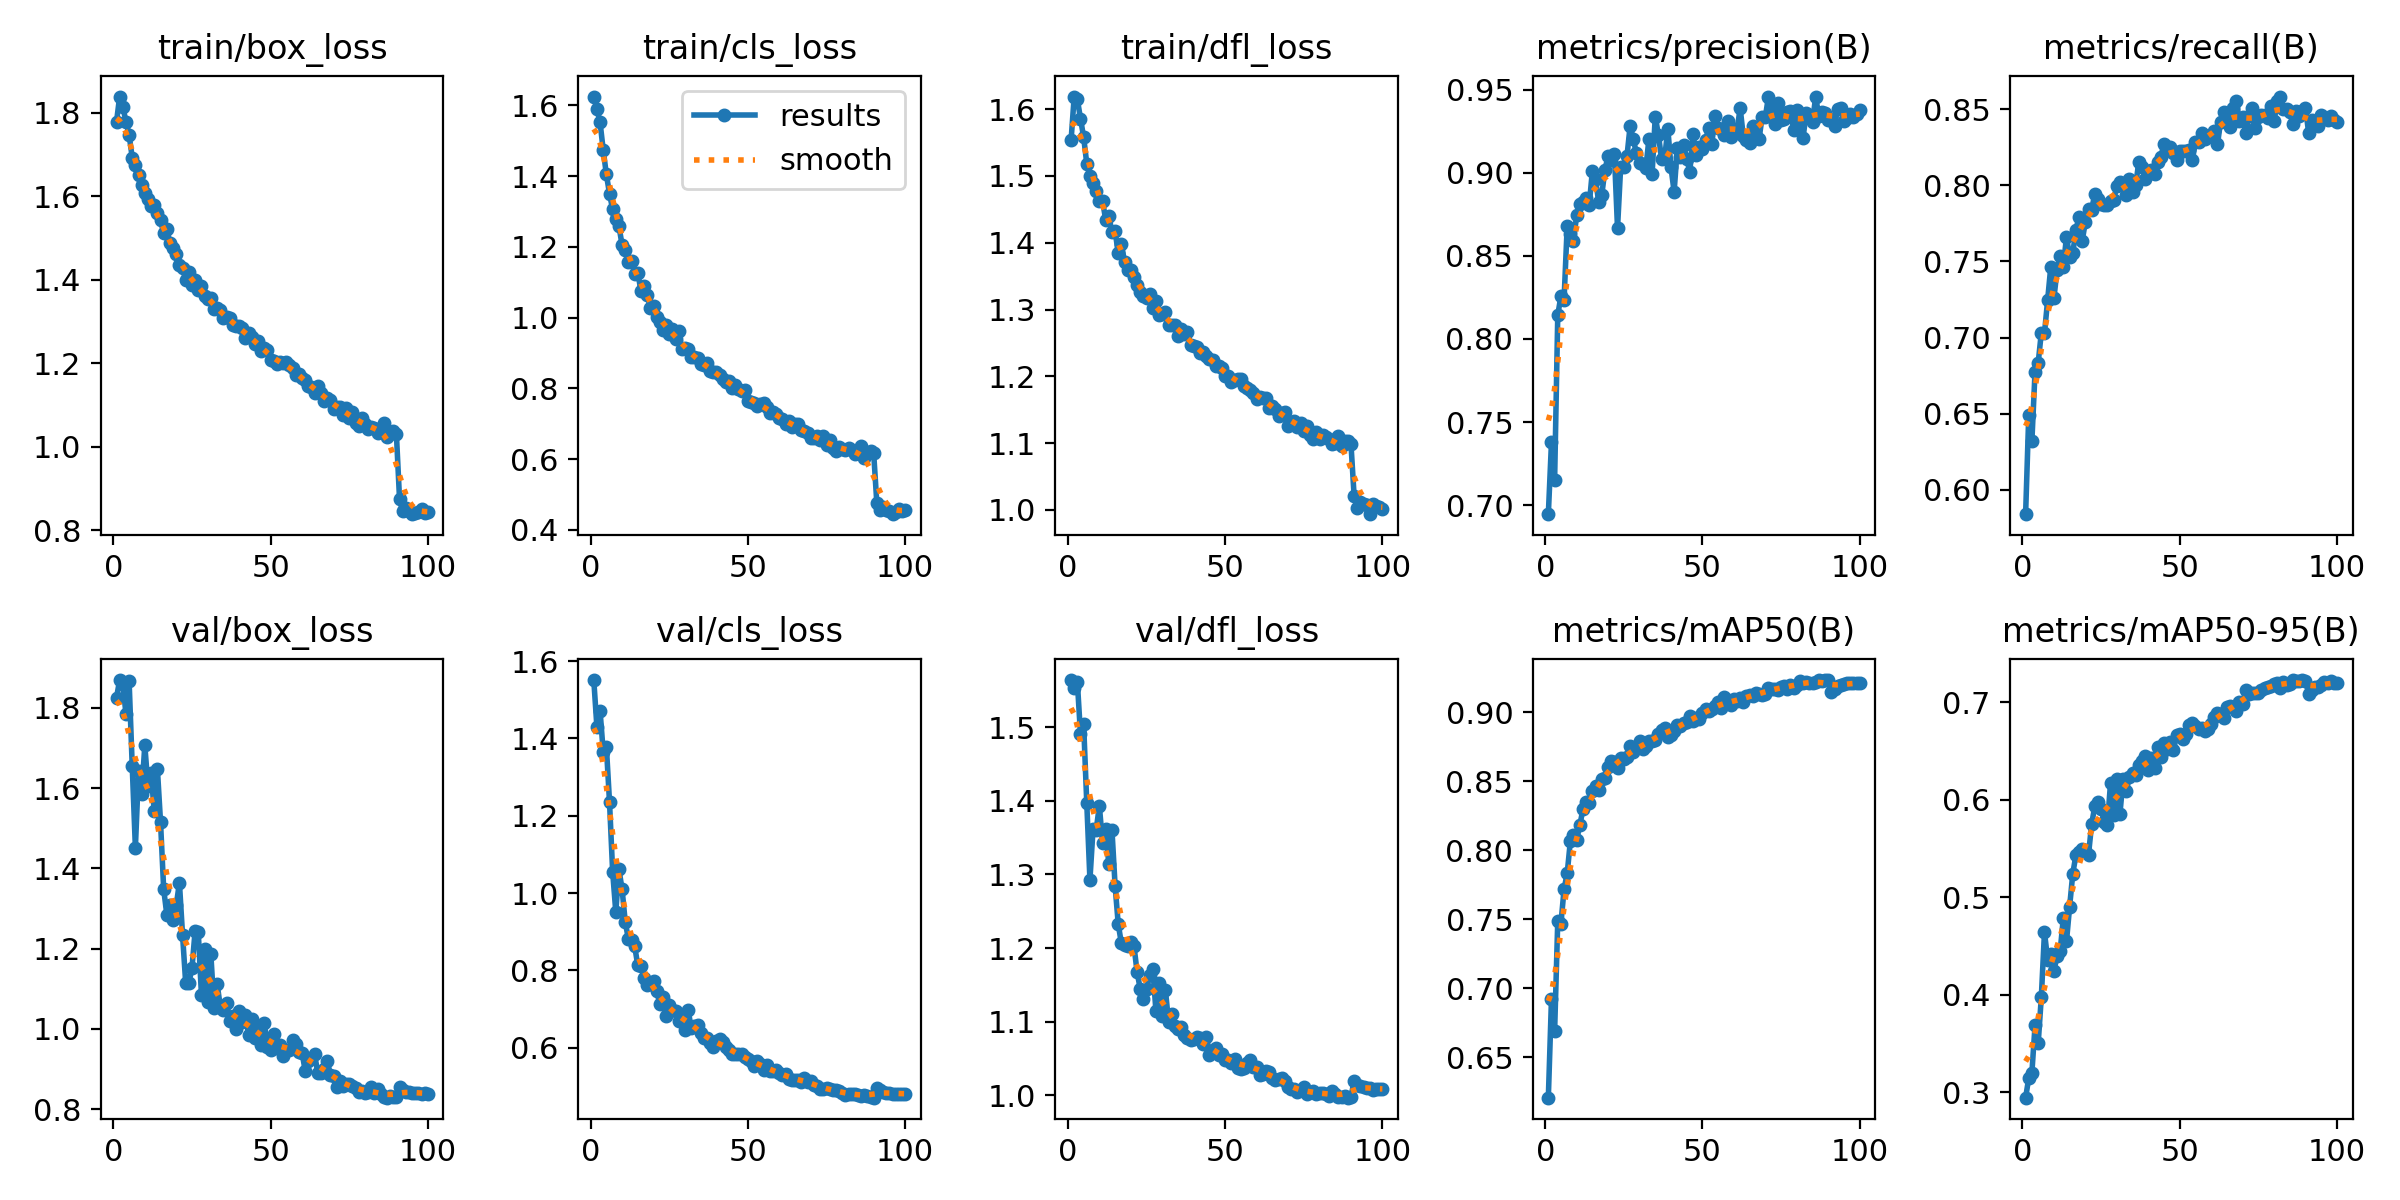

График обучения загружен

Примеры предсказаний на валидации:
----------------------------------------


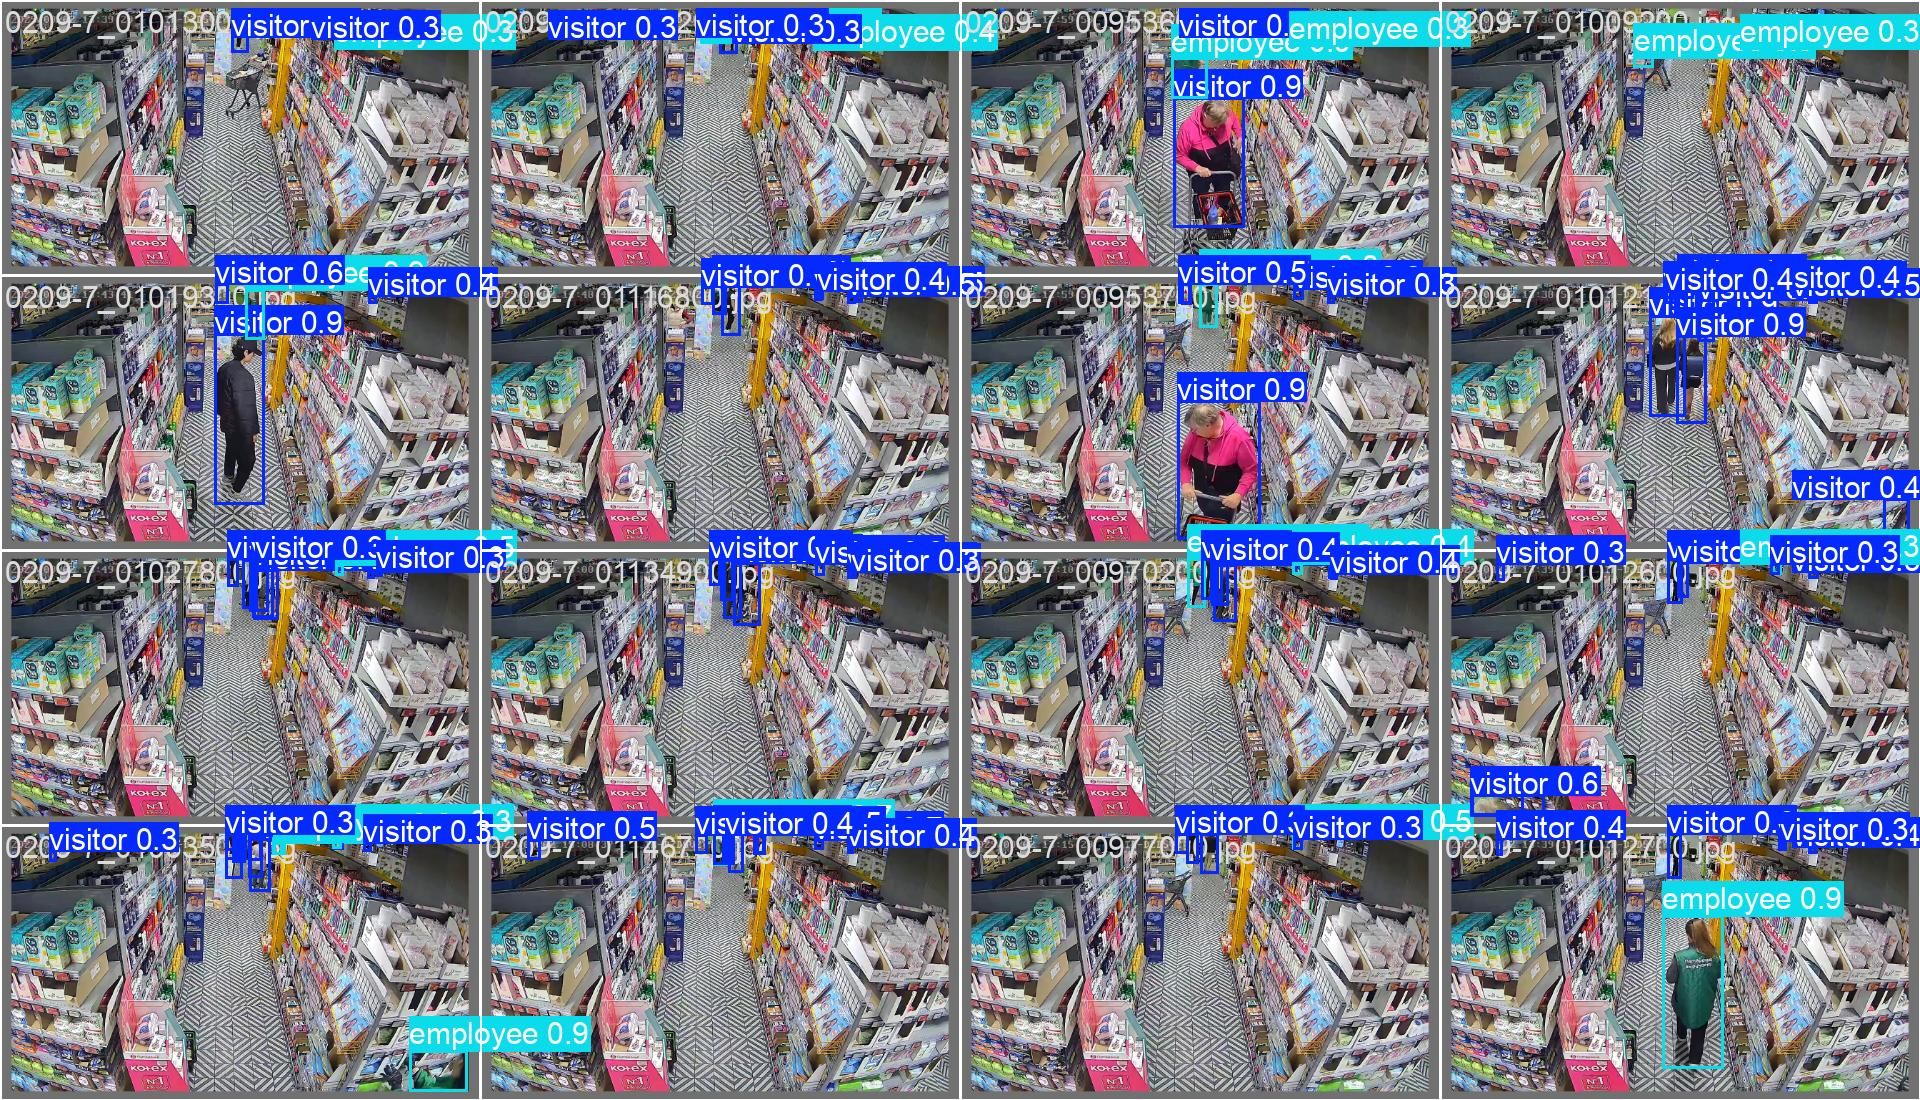

Пример предсказаний загружен


In [ ]:
from IPython.display import Image, display
from pathlib import Path

results_dir = "/content/runs/detect/miet_kfold/yolo11x.pt_fold0"

print("Графики обучения:")
print("-" * 40)

# График обучения
results_img = Path(results_dir) / 'results.png'
if results_img.exists():
    display(Image(filename=str(results_img)))
    print("График обучения загружен")
else:
    print("results.png не найден")

print("\nПримеры предсказаний на валидации:")
print("-" * 40)

# Примеры предсказаний
val_batch = Path(results_dir) / 'val_batch0_pred.jpg'
if val_batch.exists():
    display(Image(filename=str(val_batch)))
    print("Пример предсказаний загружен")
else:
    print("val_batch0_pred.jpg не найден")
    # Покажем что есть в папке
    print(f"\nСодержимое {results_dir}:")
    !ls -la {results_dir} | head -10

# Собираем итоговое предсказание

In [ ]:
from pathlib import Path
import json
import pandas as pd


def build_submission_from_solution_order(
    solution_csv: str,
    preds_dir: str,
    output_csv: str = "submission.csv",
    image_col: str = "image_name",
    boxes_col: str = "boxes",
    row_id_col: str = "id",
    require_score: bool = True,
    clamp_score: bool = True,
    keep_only_class: int | None = None,
) -> None:
    """
    Builds submission.csv in EXACTLY the same image_name order as solution.csv.

    - Reads solution_csv, takes image_name column order as ground truth order.
    - For each image_name, looks for preds_dir/<stem>.txt
      where stem is Path(image_name).stem
    - If missing -> boxes=[]
    - Prediction txt lines: class xc yc w h score
    - Output boxes: JSON [[xc,yc,w,h,score], ...]
    """
    sol_path = Path(solution_csv)
    pdir = Path(preds_dir)

    if not sol_path.exists():
        raise FileNotFoundError(f"solution_csv not found: {sol_path}")
    if not pdir.exists() or not pdir.is_dir():
        raise FileNotFoundError(f"preds_dir not found or not a dir: {pdir}")

    sol = pd.read_csv(sol_path)
    if image_col not in sol.columns:
        raise ValueError(f"solution.csv must contain column '{image_col}'")

    image_names = sol[image_col].astype(str).tolist()

    rows = []
    for idx, image_name in enumerate(image_names):
        stem = Path(image_name).stem
        pred_file = pdir / f"{stem}.txt"

        boxes = []
        if pred_file.exists():
            content = pred_file.read_text(encoding="utf-8", errors="replace").strip()
            if content:
                for ln in content.splitlines():
                    ln = ln.strip()
                    if not ln:
                        continue
                    parts = ln.split()
                    if require_score and len(parts) < 6:
                        continue
                    if len(parts) < 5:
                        continue

                    try:
                        cls = int(float(parts[0]))
                        if keep_only_class is not None and cls != keep_only_class:
                            continue

                        xc = float(parts[1])
                        yc = float(parts[2])
                        w = float(parts[3])
                        h = float(parts[4])
                        sc = float(parts[5]) if len(parts) >= 6 else 1.0
                    except ValueError:
                        continue

                    if clamp_score:
                        sc = 0.0 if sc < 0.0 else (1.0 if sc > 1.0 else sc)

                    boxes.append([xc, yc, w, h, sc])

        rows.append(
            {
                row_id_col: idx,
                image_col: image_name,
                boxes_col: json.dumps(boxes, separators=(",", ":")),
            }
        )

    sub = pd.DataFrame(rows, columns=[row_id_col, image_col, boxes_col])
    sub.to_csv(output_csv, index=False)
    print(f"Saved: {output_csv} ({len(sub)} rows). Missing preds filled with [] in solution order.")

In [ ]:
# Проверим, что папка с предсказаниями существует
preds_dir = "/content/runs/detect/predict_lab2/labels"
if not os.path.exists(preds_dir):
    print(f"Папка не найдена: {preds_dir}")
    print("Поиск папок с лейблами:")
    !find /content/runs/detect -name "labels" -type d
else:
    num_files = len(list(Path(preds_dir).glob("*.txt")))
    print(f"Найдено {num_files} файлов с предсказаниями")

    build_submission_from_solution_order(
        solution_csv="/root/.cache/kagglehub/competitions/dl-lab-2-stuff-detection/sample_sub.csv",
        preds_dir=preds_dir,
        output_csv="submission.csv",
        keep_only_class=1,
    )

Найдено 4454 файлов с предсказаниями
Saved: submission.csv (4454 rows). Missing preds filled with [] in solution order.


In [ ]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

# Загрузите вашу модель
model = YOLO('/content/runs/detect/miet_kfold/yolo11x.pt_fold0/weights/best.pt')

# Проверим, что data.yaml существует
data_yaml = "/content/split_dataset/data.yaml"
if not os.path.exists(data_yaml):
    print(f"data.yaml не найден: {data_yaml}")
else:
    # Запустите валидацию
    metrics = model.val(data=data_yaml)

    print("-" * 60)
    print("AP[0.5:0.95] Результаты:")

    print(f"\nОбщие метрики:")
    print(f"   mAP50-95 (AP[0.5:0.95]): {metrics.box.map:.4f}")
    print(f"   mAP50 (AP@0.5): {metrics.box.map50:.4f}")

    print(f"\nПо классам:")
    class_names = ['visitor', 'employee']
    for i, name in enumerate(class_names):
        print(f"\n   {name.upper()}:")
        print(f"     AP[0.5:0.95]: {metrics.box.maps[i]:.4f}")
        print(f"     AP@0.5: {metrics.box.ap50[i]:.4f}")
        print(f"     Precision: {metrics.box.p[i]:.4f}")
        print(f"     Recall: {metrics.box.r[i]:.4f}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11x summary (fused): 191 layers, 56,829,334 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3305.8±458.9 MB/s, size: 474.0 KB)
val: Scanning /content/split_dataset/val/labels... 782 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 782/782 1.4Kit/s 0.6s
val: /content/split_dataset/val/images/0209-10_00974200.jpg: 1 duplicate labels removed
val: /content/split_dataset/val/images/0209-26_00871800.jpg: 1 duplicate labels removed
val: /content/split_dataset/val/images/0209-35_00882200.jpg: 1 duplicate labels removed
val: New cache created: /content/split_dataset/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 7.1it/s 6.9s
                   all        782       4097       0.93      0.864      0.922      0.731
               visitor        689       3302       0.91     